In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_name = "Base_Contenido_1000_Registros_Reales_Categorias.xlsx"

try:
    df = pd.read_excel(file_name)
    print("Archivo cargado correctamente.")
    print(f"Total de registros: {len(df)}")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

Archivo cargado correctamente.
Total de registros: 10000


In [3]:
df.head()

,titulo,autores,editorial,isbn,anio_publicacion,descripcion,idioma,materias,url_openlibrary,categoria_nlp,categoria_macro
0,Learning Python,Mark Lutz; David Ascher,NaN,NaN,1999.0,Describes the features of the Python 2.5 progr...,NaN,NaN,NaN,Programación Python General,Programación y Desarrollo
1,Python For Data Analysis,Wes McKinney,NaN,NaN,2012.0,Serves as an introduction to Python for data-i...,NaN,NaN,NaN,Ciencia de Datos y Analítica,IA y Ciencia de Datos
2,Python Cookbook,Alex Martelli; David Ascher; David M. Beazley;...,NaN,NaN,2002.0,NaN,NaN,NaN,NaN,Programación Python General,Programación y Desarrollo
3,Python,Mark Lutz,NaN,NaN,1998.0,"<p>Python is optimized for quality, productivi...",NaN,NaN,NaN,Programación Python General,Programación y Desarrollo
4,Fluent Python,Luciano Ramalho,NaN,NaN,2015.0,NaN,NaN,NaN,NaN,Programación Python General,Programación y Desarrollo


In [4]:
print("--- Valores Nulos ---")
print(df.isnull().sum())

print("\n--- Duplicados ---")
print(f"Registros duplicados: {df.duplicated().sum()}")

--- Valores Nulos ---
titulo                  0
autores               426
editorial           10000
isbn                10000
anio_publicacion      270
descripcion          9817
idioma              10000
materias            10000
url_openlibrary     10000
categoria_nlp           0
categoria_macro         0
dtype: int64

--- Duplicados ---
Registros duplicados: 0


Dataset ajustado de 10000 a 1258 registros balanceados.

Distribución balanceada por categoría:
categoria_nlp
Programación Python General                   300
Ciencia de Datos y Analítica                  300
Inteligencia Artificial y Machine Learning    300
Desarrollo Web                                141
Ciberseguridad                                127
Redes y DevOps                                 90
Name: count, dtype: int64


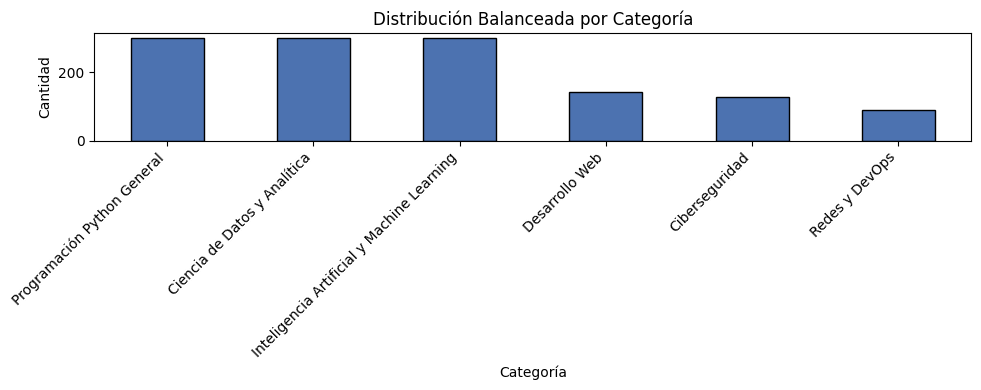

In [6]:
col_cat = [col for col in df.columns if 'cat' in col.lower()]

if col_cat:
    cat_name = col_cat[0]

    categorias_validas = [
        'Programación Python General', 'Ciencia de Datos y Analítica',
        'Inteligencia Artificial y Machine Learning', 'Desarrollo Web',
        'Ciberseguridad', 'Redes y DevOps'
    ]
    df_filtrado = df[df[cat_name].isin(categorias_validas)].copy()

    df_balanced = df_filtrado.groupby(cat_name).head(300)
    print(f"Dataset ajustado de {len(df)} a {len(df_balanced)} registros balanceados.\n")

    conteo_balanced = df_balanced[cat_name].value_counts()
    print("Distribución balanceada por categoría:")
    print(conteo_balanced)

    plt.figure(figsize=(10, 4))
    conteo_balanced.plot(kind='bar', color='#4C72B0', edgecolor='black')
    plt.title('Distribución Balanceada por Categoría')
    plt.xlabel('Categoría')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró la columna de categoría. Columnas disponibles:", df.columns.tolist())